# Week 2 core lab: Multicomponent Steady-State MLP
# 2주차 필수 실습: 다성분 정상상태 MLP

Surrogate Modeling for Process Prediction and Optimization
공정 예측과 최적화를 위한 서로게이트 모델링

Train and evaluate the steady-state predictor. Operating-selection sections are optional previews for Weeks 5-8.
정상상태 predictor를 학습하고 평가합니다. 운전점 선택 절은 5-8주차의 선택 미리보기입니다.


## 1. Inputs, outputs, and units / 입력·출력·단위

Inputs: temperature (K), residence time (min), feed A concentration (mol/L). Outputs: A, B, C concentrations (mol/L).
입력은 온도·체류시간·유입 A 농도이고, 출력은 A·B·C 농도입니다.


In [1]:
import argparse
import csv
import json
import platform
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
from torch import nn

LOWER = np.array([300.0, 1.0, 0.8])
UPPER = np.array([360.0, 10.0, 1.5])
SPECIES = ('A', 'B', 'C')
DT = 0.2
HORIZON = 30.0


def write_json(path, value):
    Path(path).write_text(json.dumps(value, indent=2, allow_nan=False) + '\n', encoding='utf-8')


def write_csv(path, header, rows):
    with Path(path).open('w', newline='', encoding='utf-8') as stream:
        writer = csv.writer(stream)
        writer.writerow(header)
        writer.writerows(rows)




## 2. Reference balances / 기준 물질수지

A → B → C; first-order reactions in a perfectly mixed, constant-volume isothermal CSTR.
완전혼합·일정 부피·등온 CSTR의 1차 연속반응 A → B → C를 사용합니다.


In [2]:
def rate_constants(temperature):
    temperature = np.asarray(temperature, dtype=float)
    return (0.2 * np.exp(6000.0 * (1.0 / 330.0 - 1.0 / temperature)),
            0.1 * np.exp(5000.0 * (1.0 / 330.0 - 1.0 / temperature)))


def steady_state(inputs):
    """[T (K), tau (min), feed (mol/L)] -> [C_A, C_B, C_C] (mol/L)."""
    inputs = np.asarray(inputs, dtype=float)
    temperature, tau, feed = inputs.T
    k1, k2 = rate_constants(temperature)
    ca = feed / (1.0 + k1 * tau)
    cb = k1 * tau * ca / (1.0 + k2 * tau)
    cc = k2 * tau * cb
    return np.column_stack((ca, cb, cc))


def concentration_rate(states, controls):
    states, controls = np.asarray(states), np.asarray(controls)
    ca, cb, cc = states.T
    temperature, tau, feed = controls.T
    k1, k2 = rate_constants(temperature)
    return np.column_stack(((feed - ca) / tau - k1 * ca,
                            -cb / tau + k1 * ca - k2 * cb,
                            -cc / tau + k2 * cb))


def reference_step(states, controls, dt=DT):
    """Analytic concentration update with constant inputs over one interval."""
    states, controls = np.asarray(states, dtype=float), np.asarray(controls, dtype=float)
    equilibrium = steady_state(controls)
    k1, k2 = rate_constants(controls[:, 0])
    q = 1.0 / controls[:, 1]
    a, b = q + k1, q + k2
    ea, eb = np.exp(-a * dt), np.exp(-b * dt)
    difference = b - a
    coupling = np.empty_like(difference)
    regular = np.abs(difference) > 1e-10
    coupling[regular] = ea[regular] * (-np.expm1(-difference[regular] * dt)) / difference[regular]
    coupling[~regular] = dt * ea[~regular]
    ca = equilibrium[:, 0] + (states[:, 0] - equilibrium[:, 0]) * ea
    cb = (equilibrium[:, 1] + (states[:, 1] - equilibrium[:, 1]) * eb
          + k1 * (states[:, 0] - equilibrium[:, 0]) * coupling)
    total = controls[:, 2] + (states.sum(axis=1) - controls[:, 2]) * np.exp(-q * dt)
    return np.column_stack((ca, cb, total - ca - cb))




In [3]:
np.testing.assert_allclose(steady_state([[330, 5, 1.2]]), [[0.6, 0.4, 0.2]], atol=1e-12)
print(steady_state([[330, 5, 1.2]]))


[[0.6 0.4 0.2]]


## 3. Forward, loss, backward, update / MLP 학습

The 3 → 32 → 32 → 3 MLP learns all three concentrations. Inputs use the declared box; outputs use train-set statistics.
세 농도를 함께 학습합니다. 입력 scaling에는 운전 영역을, 출력 scaling에는 train 통계량을 사용합니다.


In [4]:
def make_model(input_size):
    return nn.Sequential(nn.Linear(input_size, 32), nn.ReLU(),
                         nn.Linear(32, 32), nn.ReLU(), nn.Linear(32, 3))


def fit_mlp(x_train, y_train, x_val, y_val, *, seed=42, epochs=1400,
            batch_size=64, normalize_output=True, input_bounds=None):
    torch.set_num_threads(1)
    torch.manual_seed(seed)
    torch.use_deterministic_algorithms(True)
    if input_bounds is None:
        x_mean, x_scale = x_train.mean(axis=0), x_train.std(axis=0)
    else:
        lower, upper = input_bounds
        x_mean, x_scale = (lower + upper) / 2.0, (upper - lower) / 2.0
    x_scale = np.maximum(x_scale, 1e-8)
    y_mean = y_train.mean(axis=0) if normalize_output else np.zeros(3)
    y_scale = np.maximum(y_train.std(axis=0), 1e-8) if normalize_output else np.ones(3)
    train_x = torch.tensor((x_train - x_mean) / x_scale, dtype=torch.float32)
    train_y = torch.tensor((y_train - y_mean) / y_scale, dtype=torch.float32)
    val_x = torch.tensor((x_val - x_mean) / x_scale, dtype=torch.float32)
    val_y = torch.tensor((y_val - y_mean) / y_scale, dtype=torch.float32)
    model = make_model(x_train.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_function = nn.MSELoss()
    history, best_loss, best_epoch, best_weights = [], float('inf'), 0, None
    for epoch in range(1, epochs + 1):
        model.train()
        order = torch.randperm(len(train_x))
        for indices in order.split(batch_size):
            prediction = model(train_x[indices])
            loss = loss_function(prediction, train_y[indices])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            train_loss = float(loss_function(model(train_x), train_y))
            val_loss = float(loss_function(model(val_x), val_y))
        history.append([epoch, train_loss, val_loss])
        if val_loss < best_loss:
            best_loss, best_epoch = val_loss, epoch
            best_weights = {key: value.detach().clone() for key, value in model.state_dict().items()}
        if epoch % 400 == 0:
            print(f'epoch {epoch}: train={train_loss:.6g}, validation={val_loss:.6g}')
        if epoch - best_epoch >= 180:
            break
    model.load_state_dict(best_weights)
    model.eval()
    scaling = {name: value.tolist() for name, value in
               [('x_mean', x_mean), ('x_scale', x_scale), ('y_mean', y_mean), ('y_scale', y_scale)]}
    scaling.update(input_size=x_train.shape[1], output_size=3, seed=seed,
                   best_epoch=best_epoch, trained_epochs=epoch, output_normalized=normalize_output)
    return model, scaling, np.asarray(history)


def predict(model, scaling, inputs):
    scaled = (np.asarray(inputs) - scaling['x_mean']) / scaling['x_scale']
    with torch.no_grad():
        result = model(torch.tensor(scaled, dtype=torch.float32)).numpy()
    return result * scaling['y_scale'] + scaling['y_mean']


def save_model(directory, name, model, scaling):
    torch.save(model.state_dict(), directory / f'{name}.pt')
    write_json(directory / f'{name}-scaling.json', scaling)


def load_model(directory, name):
    directory = Path(directory)
    scaling = json.loads((directory / f'{name}-scaling.json').read_text(encoding='utf-8'))
    model = make_model(scaling['input_size'])
    model.load_state_dict(torch.load(directory / f'{name}.pt', map_location='cpu', weights_only=True))
    model.eval()
    return model, scaling


def prediction_metrics(truth, prediction, feed):
    error = np.asarray(prediction) - np.asarray(truth)
    residual = np.asarray(prediction).sum(axis=-1) - feed
    return {'rmse_mol_L': np.sqrt(np.mean(error ** 2, axis=0)).tolist(),
            'balance_rmse_mol_L': float(np.sqrt(np.mean(residual ** 2))),
            'minimum_predicted_concentration_mol_L': float(np.min(prediction))}


def plot_history(history, path, title):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.semilogy(history[:, 0], history[:, 1], label='Train')
    ax.semilogy(history[:, 0], history[:, 2], label='Validation')
    ax.set(xlabel='Epoch', ylabel='Scaled MSE', title=title)
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.close(fig)




## 4. One backpropagation calculation / Backpropagation 한 번 계산하기

Use the given weights, loss 0.5 times squared error, and learning rate 0.1.
주어진 가중치, 제곱 오차 합의 절반, learning rate 0.1로 한 번 갱신합니다.


In [5]:
def backprop_example():
    x = torch.tensor([1., 0., -1.], dtype=torch.float64)
    target = torch.tensor([0., 1., 0.], dtype=torch.float64)
    w1 = torch.tensor([[1., 0., 0.], [0., 0., 1.]], dtype=torch.float64, requires_grad=True)
    b1 = torch.zeros(2, dtype=torch.float64, requires_grad=True)
    w2 = torch.tensor([[1., 0.], [0., 1.], [1., 1.]], dtype=torch.float64, requires_grad=True)
    b2 = torch.zeros(3, dtype=torch.float64, requires_grad=True)
    prediction = w2 @ torch.relu(w1 @ x + b1) + b2
    loss = 0.5 * ((prediction - target) ** 2).sum()
    loss.backward()
    gradients = [value.grad.detach().numpy().copy() for value in (w1, b1, w2, b2)]
    np.testing.assert_allclose(gradients[0], [[2, 0, -2], [0, 0, 0]])
    np.testing.assert_allclose(gradients[1], [2, 0])
    np.testing.assert_allclose(gradients[2], [[1, 0], [-1, 0], [1, 0]])
    np.testing.assert_allclose(gradients[3], [1, -1, 1])
    with torch.no_grad():
        for parameter in (w1, b1, w2, b2):
            parameter -= 0.1 * parameter.grad
        after = w2 @ torch.relu(w1 @ x + b1) + b2
        after_loss = 0.5 * ((after - target) ** 2).sum()
    return {'loss_before': float(loss.detach()), 'loss_after': float(after_loss),
            'prediction_after': after.tolist(), 'gradients': [value.tolist() for value in gradients]}




In [6]:
example = backprop_example()
print(json.dumps(example, indent=2))


{
  "loss_before": 1.5,
  "loss_after": 0.43740000000000007,
  "prediction_after": [
    0.2600000000000001,
    0.14,
    0.2600000000000001
  ],
  "gradients": [
    [
      [
        2.0,
        0.0,
        -2.0
      ],
      [
        0.0,
        0.0,
        -0.0
      ]
    ],
    [
      2.0,
      0.0
    ],
    [
      [
        1.0,
        0.0
      ],
      [
        -1.0,
        -0.0
      ],
      [
        1.0,
        0.0
      ]
    ],
    [
      1.0,
      -1.0,
      1.0
    ]
  ]
}


## 5. Train and compare / 학습과 비교

Fit normalized and unnormalized output models using the same dataset and initial seed. Compare concentration RMSE and balance residual.
같은 데이터·초기 seed로 출력 scaling 적용 전후를 비교합니다.


In [7]:
def generate_steady_splits(seed=42):
    rng = np.random.default_rng(seed)
    return {name: (x, steady_state(x)) for name, x in
            [(name, rng.uniform(LOWER, UPPER, (size, 3)))
             for name, size in [('train', 400), ('validation', 120), ('test', 160)]]}


def steady_figures(directory, model, scaling, test_x, test_y, test_prediction, decision):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.3))
    for j, ax in enumerate(axes):
        ax.scatter(test_y[:, j], test_prediction[:, j], s=12, alpha=0.7)
        bound = max(test_y[:, j].max(), test_prediction[:, j].max())
        ax.plot([0, bound], [0, bound], '--', color='grey')
        ax.set(xlabel='Reference (mol/L)', ylabel='MLP (mol/L)', title=f'Species {SPECIES[j]}')
    fig.tight_layout()
    fig.savefig(directory / 'steady-parity.png', dpi=160)
    plt.close(fig)
    tau = np.linspace(1, 10, 150)
    inputs = np.column_stack((np.full(len(tau), 330.0), tau, np.full(len(tau), 1.2)))
    truth, prediction = steady_state(inputs), predict(model, scaling, inputs)
    fig, ax = plt.subplots(figsize=(7, 3.8))
    for j, color in enumerate(['#0b6b57', '#cf7a20', '#244a7f']):
        ax.plot(tau, truth[:, j], color=color, label=f'{SPECIES[j]} reference')
        ax.plot(tau, prediction[:, j], '--', color=color, label=f'{SPECIES[j]} MLP')
    ax.set(xlabel='Residence time (min)', ylabel='Concentration (mol/L)', title='330 K; feed = 1.2 mol/L')
    ax.legend(ncol=2, fontsize=8)
    fig.tight_layout()
    fig.savefig(directory / 'steady-profiles.png', dpi=160)
    plt.close(fig)
    temperatures, taus = np.linspace(300, 360, 121), np.linspace(1, 10, 91)
    tt, rr = np.meshgrid(temperatures, taus)
    candidates = np.column_stack((tt.ravel(), rr.ravel(), np.full(tt.size, 1.2)))
    reference_b = steady_state(candidates)[:, 1].reshape(tt.shape)
    fig, ax = plt.subplots(figsize=(7, 4))
    image = ax.contourf(tt, rr, reference_b, levels=25, cmap='viridis')
    fig.colorbar(image, ax=ax, label='Reference C_B (mol/L)')
    ax.scatter(decision['selected_temperature_K'], decision['selected_tau_min'], marker='x', s=70, c='red', label='MLP selected')
    ax.scatter(decision['reference_temperature_K'], decision['reference_tau_min'], facecolors='none', edgecolors='white', s=80, label='Reference grid maximum')
    ax.set(xlabel='Temperature (K)', ylabel='Residence time (min)', title='Select an operating point for B production')
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(directory / 'steady-decision.png', dpi=160)
    plt.close(fig)


def run_steady(directory, seed=42, epochs=1400):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    splits = generate_steady_splits(seed)
    train_x, train_y = splits['train']
    val_x, val_y = splits['validation']
    test_x, test_y = splits['test']
    model, scaling, history = fit_mlp(train_x, train_y, val_x, val_y, seed=seed,
                                    epochs=epochs, input_bounds=(LOWER, UPPER))
    raw_model, raw_scaling, _ = fit_mlp(train_x, train_y, val_x, val_y, seed=seed,
                                     epochs=epochs, normalize_output=False, input_bounds=(LOWER, UPPER))
    prediction = predict(model, scaling, test_x)
    raw_prediction = predict(raw_model, raw_scaling, test_x)
    tt, rr = np.meshgrid(np.linspace(300, 360, 121), np.linspace(1, 10, 91))
    candidates = np.column_stack((tt.ravel(), rr.ravel(), np.full(tt.size, 1.2)))
    predicted, reference = predict(model, scaling, candidates), steady_state(candidates)
    allowed = np.all((predicted >= 0) & (predicted <= 1.2), axis=1)
    selected = int(np.argmax(np.where(allowed, predicted[:, 1], -np.inf)))
    reference_selected = int(np.argmax(reference[:, 1]))
    decision = {'selected_temperature_K': float(candidates[selected, 0]),
                'selected_tau_min': float(candidates[selected, 1]),
                'predicted_C_B_mol_L': float(predicted[selected, 1]),
                'reference_C_B_mol_L': float(reference[selected, 1]),
                'reference_temperature_K': float(candidates[reference_selected, 0]),
                'reference_tau_min': float(candidates[reference_selected, 1]),
                'reference_grid_C_B_mol_L': float(reference[reference_selected, 1]),
                'reference_yield_B': float(reference[selected, 1] / 1.2),
                'candidate_count': len(candidates)}
    metrics = {'scaled_output_model': prediction_metrics(test_y, prediction, test_x[:, 2]),
               'unscaled_output_model': prediction_metrics(test_y, raw_prediction, test_x[:, 2]),
               'decision': decision, 'best_epoch': scaling['best_epoch'],
               'trained_epochs': scaling['trained_epochs'], 'seed': seed}
    save_model(directory, 'steady-model', model, scaling)
    save_model(directory, 'steady-unscaled-model', raw_model, raw_scaling)
    write_json(directory / 'steady-results.json', metrics)
    write_csv(directory / 'steady-training.csv', ['epoch', 'train_scaled_mse', 'validation_scaled_mse'], history)
    write_csv(directory / 'steady-dataset.csv', ['split', 'T_K', 'tau_min', 'feed_mol_L', 'C_A', 'C_B', 'C_C'],
              ([name, *x, *y] for name, (xs, ys) in splits.items() for x, y in zip(xs, ys)))
    plot_history(history, directory / 'steady-training.png', 'Steady-state MLP training')
    steady_figures(directory, model, scaling, test_x, test_y, prediction, decision)
    print(json.dumps(metrics, indent=2))
    return metrics




In [8]:
steady_metrics = run_steady(Path("week02-results"), seed=42)


epoch 400: train=0.000486822, validation=0.000719781
epoch 800: train=0.000209511, validation=0.000461487
epoch 1200: train=0.000215109, validation=0.00040381
epoch 400: train=2.87667e-05, validation=3.90648e-05
epoch 800: train=1.09174e-05, validation=2.15381e-05
epoch 1200: train=8.64387e-06, validation=1.91342e-05
{
  "scaled_output_model": {
    "rmse_mol_L": [
      0.005275124114926506,
      0.0029403857147795205,
      0.004423193366032517
    ],
    "balance_rmse_mol_L": 0.0037809930059328435,
    "minimum_predicted_concentration_mol_L": 0.00023598701015659085
  },
  "unscaled_output_model": {
    "rmse_mol_L": [
      0.006633520820218193,
      0.00391677353636534,
      0.004162037124132119
    ],
    "balance_rmse_mol_L": 0.00506280499988848,
    "minimum_predicted_concentration_mol_L": -0.002178128808736801
  },
  "decision": {
    "selected_temperature_K": 360.0,
    "selected_tau_min": 1.7000000000000002,
    "predicted_C_B_mol_L": 0.45111112083714944,
    "reference_C_

### Training loss / 학습 loss


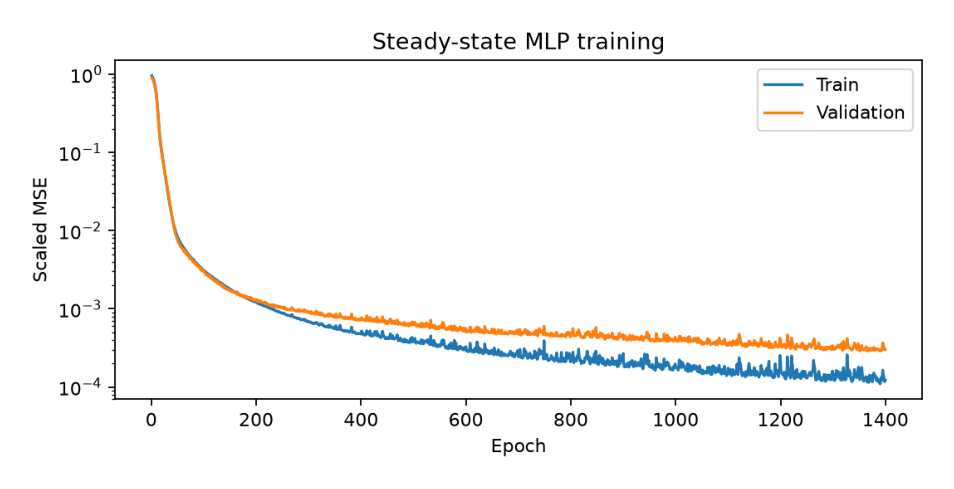

In [9]:
figure = plt.figure(figsize=(10, 7))
plt.imshow(plt.imread(Path("week02-results") / "steady-training.png"))
plt.axis("off")
plt.show()


### Parity plots / 성분별 예측


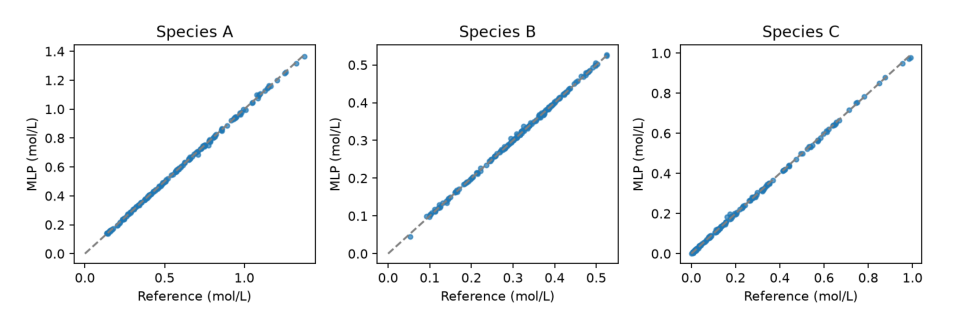

In [10]:
figure = plt.figure(figsize=(10, 7))
plt.imshow(plt.imread(Path("week02-results") / "steady-parity.png"))
plt.axis("off")
plt.show()


### Residence-time response / 체류시간 응답


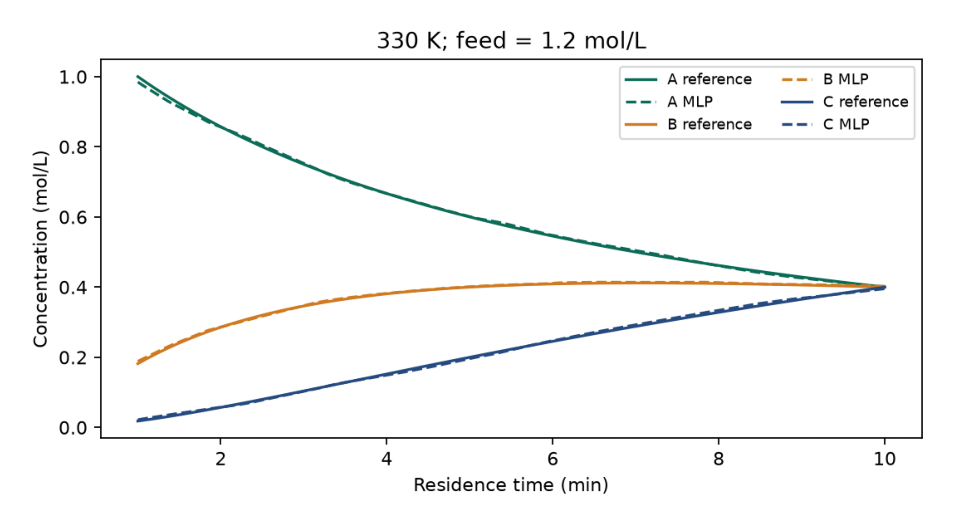

In [11]:
figure = plt.figure(figsize=(10, 7))
plt.imshow(plt.imread(Path("week02-results") / "steady-profiles.png"))
plt.axis("off")
plt.show()


**Optional later-topic preview / 후반부 선택 미리보기**

### Select an operating point / 운전점 선택


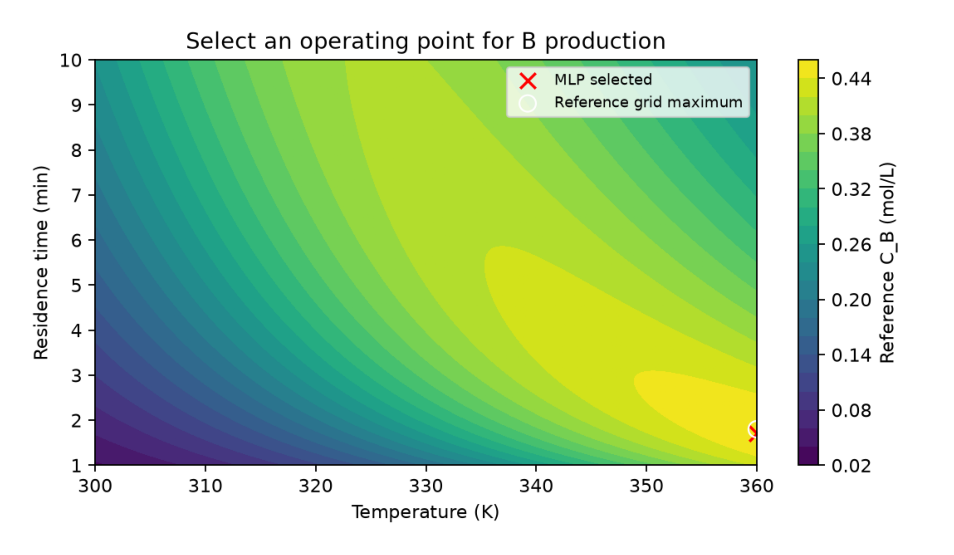

In [12]:
figure = plt.figure(figsize=(10, 7))
plt.imshow(plt.imread(Path("week02-results") / "steady-decision.png"))
plt.axis("off")
plt.show()


**Optional later-topic preview / 후반부 선택 미리보기**

## Exercises / 연습문제

1. Count the parameters of the 3 → 32 → 32 → 3 network. / Parameter 수를 계산하세요.
2. Derive the residence time maximizing B at fixed T. / 고정 T에서 B 농도를 최대화하는 체류시간을 유도하세요.
3. Compare the three RMSE values with and without output scaling. / 출력 scaling 전후의 RMSE를 비교하세요.
4. Compare the selected point with the reference grid maximum. / 선택한 운전점을 기준 grid 최대점과 비교하세요.
